In [23]:
import numpy as np
from scipy import stats
from scipy import integrate
from scipy import interpolate
import pyfftlog
import glob
from numpy import matrix
import matplotlib.pyplot as plt
import time

In [24]:
from colossus.cosmology import cosmology as colossus_cosmo
from dark_emulator import darkemu
emu = darkemu.base_class()

In [25]:
#TS: The cosmological parameters are set to the one for HACC2
n_s = 0.963
h=0.71
Omega_bh2 = 0.02258
cparam = np.array([Omega_bh2,0.2648*h**2.-Omega_bh2,h,3.094,n_s,-1.])
emu.set_cosmology(cparam)
sigma8 = emu.get_sigma8()

Omega_m0 = 0.2648
Omega_Lambda0 = 1-Omega_m0
b0 = Omega_bh2/h**2.
print(sigma8)

colossus_params = {'flat': True, 'H0': h*100., 'Om0': Omega_m0, 'Ob0': b0, 'sigma8': sigma8, 'ns': n_s, 'w0': -1.}
cosmo_col = colossus_cosmo.setCosmology('planck18')

0.7885960202471188


In [26]:
def Omega_m(z):
    return Omega_m0/(Omega_m0 + Omega_Lambda0/(1. + z)**3)

def Omega_Lambda(z):
    return Omega_Lambda0/(Omega_m0*(1. + z)**3 + Omega_Lambda0)

def Ddiff_f(z): # 0.03 < Ω_m < 2, -5 < Ω_Λ < 5 で比較的正確
    return Omega_m(z)**(4./7.) + Omega_Lambda(z)/70. * (1. + Omega_m(z)/2.)

# mPk_nw ######################################################################################################

# ゼロbaryonの遷移関数 Eisenstein & Hu 1998 ####################################################################
def initialized_q(k):
    return k * (2.728/2.7)**2./Gamma_eff(k) # $2.728 \pm 0.004$ K :  Fixsen et al. 1996

def Gamma_eff(k):
    alpha_g = 1. - 0.328 * np.log(431. * Omega_m0 * h**2.) * b0/Omega_m0 \
                + 0.38 * np.log(22.3 * Omega_m0 * h**2.) * (b0/Omega_m0)**2.
    s = 44.5 * np.log(9.83/Omega_m0/h**2.)/np.sqrt(1. + 10. * (b0 * h**2.)**(3./4.)) * h #[Mpc/h]
    
    return Omega_m0 * h * ( alpha_g + (1. - alpha_g)/(1. + (0.43 * k * s)**4.) )

def transfer_func(q):
    L0 = np.log(2. * np.exp(1.0) + 1.8 * q)
    C0 = 14.2 + 731./(1. + 62.5 * q)
    
    return L0/(L0 + C0 * q**2.)


# mPkと遷移関数との関係 ########################################################################################
def Window_func(k, R): # R = 8 Mpc/h Top hat型 window function(8.18)
    return 3./(k * R)**3. * (np.sin(k * R) - k * R * np.cos(k * R))

def Int(k):
    return integrate.simpson(k**(n_s + 2.) * Window_func(k, 8.)**2. * transfer_func(initialized_q(k))**2., k) # (8.35)

def Amplitude0(k):
    return sigma8**2. * (2. * np.pi**2.)/Int(k) # Amplitude



def P_nw(k,z): # nowiggleなmPk (8.34) [Mpc^3/h^3]
    return Amplitude0(k) * emu.Dgrowth_from_z(z)**2. * k**n_s * transfer_func(initialized_q(k))**2.

# mPk_fiducial #################################################################################################

def mPk_fiducial(k, z, Sigma_a): #[Mpc^3/h^3] 
    Sigma_m = Sigma_a * emu.Dgrowth_from_z(z)/emu.Dgrowth_from_z(0.0) # [Mpc/h] Seo et al. 2012 7.527
    
    pklin = emu.get_pklin_from_z(k,z) # [Mpc^3/h^3]
    return (pklin - P_nw(k, z))*np.exp(-k**2. * Sigma_m**2./2.) + P_nw(k, z)



In [27]:
def hankel_transform(n, kr, q, mu, dlnr, Ar):
    """executing Hankel transformation
    Args:
        n (int): binning number of fftlog
        kr (float): Product of k_c and r_c where 'c' indicate the center of scale array, r and k.
        q (flaot): bias index for fftlog.
        mu (float): mu of Bessel function.
        dlnr (float): bin width in logarithmic
        Ar (ndarray): array of input function
    Returns:
        Ak (ndarray): Hankel-transformed array.
    """
    _kr, xsave = pyfftlog.fhti(n, mu, dlnr, q, kr, 0)
    Ak = pyfftlog.fht(Ar.copy(), xsave, 1) # execute fftlog     Fast Hankel Transform 
    return Ak

class fftlog:
    """pyfftlog wrapper class
    """
    def __init__(self, num=1, logrmin=np.log10(20), logrmax=np.log10(160), kr=1):
        """
        Args:
            num (int,optional): Binning number of fftlog in unit of 2048.
            logrmin (float, optional): Minimum r over which scale fftlog will be executed.
            logrmax (float, optional): Maximum r under which scale fftlog will be executed.
            kr (float, optional): Product of k_c and r_c where 'c' indicate the center of scale array, r and k.
        """
        self.n = n = 2048 * num
        logrmin = logrmin
        logrmax = logrmax
        self.kr = kr
        nc = float(n+1.)/2.

        # array in real space
        logrc = (logrmin + logrmax)/2.
        dlogr = (logrmax - logrmin)/n
        self.dlnr = dlogr*np.log(10.0)
        self.r = 10.**(logrc + (np.arange(1, n+1) - nc) * dlogr)
        print("self.r", self.r)

        # array in Fourier space
        logkc = np.log10(kr) - logrc
        logkmin = np.log10(kr) - logrmax
        logkmax = np.log10(kr) - logrmin
        dlogk = (logkmax - logkmin)/n
        self.dlnk = dlogk * np.log(10.)
        self.k = 10.**(logkc + (np.arange(1, n+1) - nc) * dlogk)

    def HT(self, Ar, mu, q, beta=0, prefactor=1):
        """Hankel transform
        Executing Hankel transformation, defined as
        .. math::
            A(k) = p k^{\\beta} \\int_0^{\\infty} k {\\rm d}r A(r) (kr)^{q} J_{\\mu}(kr).
        where :math:`p` is arbitrary prefactor.
        Args:
            Ar (ndarray): Array of numeric values of function A(r=self.r).
            mu (float): Order of the first kind of Bessel function, :math:`J_\\mu`.
            q (float): Bias parameter in FFTLog
            beta (float): Power index of k to be multiplied to output
            prefactor (float, ndarray): Constant prefactor to be multiplied to output
        Returns:
            Ak (ndarray): Approximated Hannkel transformation of Ar on k=self.k, defined as
        """
        return prefactor * self.k**beta * hankel_transform(self.n, self.kr, q, mu, self.dlnr, Ar)

    def iHT(self, Ak, mu, q, beta, prefactor):
        """inverse Hankel transform
        Executing inverse Hankel transformation, defined as
        .. math::
            A(r) = p r^{\\beta} \\int_0^{\\infty} r {\\rm d}k A(k) (kr)^{q} J_{\\mu}(kr).
        where :math:`p` is arbitrary prefactor.
        Args:
            Ak (ndarray): Array of numeric values of function A(k=self.rk).
            mu (float): Order of the first kind of Bessel function, :math:`J_\\mu`.
            q (float): Bias parameter in FFTLog
            beta (float): Power index of r to be multiplied to output
            prefactor (float, ndarray): Constant prefactor to be multiplied to output
        Returns:
            Ar (ndarray): Approximated Hannkel transformation of Ak on r=self.r, defined as
        """
        return prefactor * self.r**beta * hankel_transform(self.n, self.kr, q, mu, self.dlnk, Ak)

    # pk2xi 1D
    def pk2xi(self, r_sep, z, Sigma_a, idx_shift=0.0):
        """converting P(k) to xi(r)
        Converting 3-dimensional power spectrum into 3-dimensional correlation function, defined as
        .. math::
            \\xi(r) = \\int \\frac{{\\rm d}^{3}k}{(2\\pi)^3} P(k) e^{i k\cdot r}
                    = \\frac{1}{(2\\pi r)^{3/2+s}} \\int r{\\rm d}k [k^{3/2-s}P(k)] (kr)^{\\rm s} J_{1/2}(kr)
        where :math:`s` is shift index used for fftlog to converge. Note that the resultant :math:`\\xi` is independent from shift index.
        Args:
            pk (ndarray): Array of P(k=self.k)
            idx_shift (float): Power index, used for tune fftlog to converge.
        Returns:
            xi (ndarray): Array of correlation function, xi.
        """
        
        pk = mPk_fiducial(self.k, z, Sigma_a)
        #pk = np.array([cosmo.pk_lin(kk,0.) for kk in self.k * h]) # [Mpc^3]
        
        xi = self.iHT(Ak=self.k**(1.5-idx_shift)*pk, mu=0.5, q=idx_shift, beta=-1.5-idx_shift, prefactor=(2.0*np.pi)**(-1.5) )
        xi_interp = interpolate.interp1d(self.r, xi)
        return xi_interp(r_sep)

In [28]:
class BAO:
    def __init__(self,k,z=0.15,Sigma_a=10.,r_range=[0.1,250.],r_bin=100):
        self.pk = mPk_fiducial(k, z, Sigma_a)
        self.k = k
        self.z = z
        self.Sigma_a = Sigma_a
        self.r = np.linspace(r_range[0],r_range[1],r_bin)
        
    def calc_fourierTransform(self):
        hankel = fftlog(num=1, logrmin=np.log10(0.0005), logrmax=np.log10(100000), kr=1)
        self.xi = hankel.pk2xi(r_sep=self.r, z=self.z, Sigma_a=self.Sigma_a, idx_shift=0.)
        return self.r, self.xi
        

    def xi_fit(self,r,alpha,B,A0,A1,A2):
        f_xi = interpolate.interp1d(self.r,self.xi,kind='linear')
        return B*f_xi(alpha*r)+A0+A1/r+A2/r**2.

    def calc_chiSquare(self,r_obs,xi_obs,cov,alpha,B,A0,A1,A2):
        cov = matrix(cov)
        xi_fit = self.xi_fit(r_obs,alpha,B,A0,A1,A2)
        vector = np.inner(xi_obs-xi_fit,cov.I)
        return np.inner(vector,xi_obs-xi_fit)


    def find_linearParams(self,r_obs,xi_obs,cov_inv,alpha):
        f_xi = interpolate.interp1d(self.r,self.xi,kind='linear')
        num = np.shape(r_obs)[0]
        xi_nw = f_xi(alpha*r_obs)
        matA = np.array((xi_nw,np.ones(num),1./r_obs,1/r_obs**2.))
        matA2 = np.inner(matA,cov_inv)
        matA3 = matrix(np.inner(matA2,matA))
        beta=np.inner(matA2,xi_obs)
        params = np.inner(matA3.I,beta)
        return params
        
    def least_squareFit(self,r_obs,xi_obs,cov,num=300):
        cov = matrix(cov)
        cov_inv = cov.I

        alphas = np.linspace(0.8,1.2,num=num)
        chis = np.zeros(num)
        params = np.zeros((num,4))
                     
        for i,alpha in enumerate(alphas):
            params[i] = np.ndarray.flatten(self.find_linearParams(r_obs,xi_obs,cov_inv,alpha))
            chis[i] = self.calc_chiSquare(r_obs,xi_obs,cov,alpha,params[i,0],params[i,1],params[i,2],params[i,3])
         
        return chis,alphas,params

In [29]:
def from_xi2d(filename):
    data = np.loadtxt(filename)
    s_bin = np.unique(data[:,0])
    mu_bin = np.unique(data[:,1])
    num_s = np.shape(s_bin)[0]
    num_mu = np.shape(mu_bin)[0]
    xi2d = np.zeros((num_s,num_mu))
    for i in range(num_s):
        for j in range(num_mu):
            test = (data[:,0]==s_bin[i]) & (data[:,1]==mu_bin[j])
            if np.shape(data[test])[0]!=0:
                xi2d[i,j] = data[test][:,2][0]
    return s_bin,mu_bin,xi2d

def from_xi2d_to_xi0(filename):
    data = np.loadtxt(filename)
    s_bin = np.unique(data[:,0])
    num_s = np.shape(s_bin)[0]
    xi = np.zeros(num_s)
    for i in range(num_s):
        test = (data[:,0]==s_bin[i])
        if np.shape(data[test])[0]!=0:
            xi[i] = np.mean(data[test][:,2])
    return s_bin,xi

In [30]:
def rebin_xi0(r_bin,xi,new_r):
    nbin = len(new_r)
    new_xi = np.zeros(nbin-1)
    for i in np.arange(nbin-1):
        test = (r_bin>=new_r[i])&(r_bin<new_r[i+1])
        new_xi[i] = np.mean(xi[test])
    return new_xi

In [99]:
files_true = glob.glob('./pfs4/subhacc_pfs4_r_rlz*-xi2d.dat')
files_fiber = glob.glob('./pfs4/pfs4_hacc_s_naive_rlz*-xi2d.dat')
files_true.sort()
files_fiber.sort()
print(len(files_true))
print(len(files_fiber))
print(files_true[:5])
print(files_fiber[:5])
n_file_true = len(files_true)
n_file_fiber = len(files_fiber)
rbin = np.linspace(40.,160.,21) #TS: Define the radial bin to fit
rmid = (rbin[1:]+rbin[:-1])/2.
xis_true = np.zeros((n_file_true,np.shape(rmid)[0]))
xis_fiber = np.zeros((n_file_fiber,np.shape(rmid)[0]))

for i in np.arange(n_file_true):
    rr_true,xi_true = from_xi2d_to_xi0(files_true[i])
    xis_true[i] = rebin_xi0(rr_true,xi_true,rbin)

for i in np.arange(n_file_fiber):
    rr_fiber,xi_fiber= from_xi2d_to_xi0(files_fiber[i])
    xis_fiber[i] = rebin_xi0(rr_fiber,xi_fiber,rbin)

cov = np.cov(xis.T)
num=100 #TS: the number of bins to compute chi-square, alpha, and nuisance parameters
chis_true = np.zeros((n_file_true,num))
alphas_true = np.zeros((n_file_true,num))
params_true = np.zeros((n_file_true,num,4))

chis_fiber = np.zeros((n_file_fiber,num))
alphas_fiber = np.zeros((n_file_fiber,num))
params_fiber = np.zeros((n_file_fiber,num,4))

tmp = BAO(np.logspace(-2.5,0,50),z=0.15,Sigma_a=5.)
tmp_r,tmp_xi = tmp.calc_fourierTransform()

start = time.time()
for i in np.arange(n_file_true):
    chis_true[i],alphas_true[i],params_true[i] = tmp.least_squareFit(rmid,xis_true[i],cov,num=num)

for i in np.arange(n_file_fiber):
    chis_fiber[i],alphas_fiber[i],params_fiber[i] = tmp.least_squareFit(rmid,xis_fiber[i],cov,num=num)
    
print(time.time()-start)

110
115
['./pfs4/subhacc_pfs4_r_rlz1-xi2d.dat', './pfs4/subhacc_pfs4_r_rlz102-xi2d.dat', './pfs4/subhacc_pfs4_r_rlz104-xi2d.dat', './pfs4/subhacc_pfs4_r_rlz105-xi2d.dat', './pfs4/subhacc_pfs4_r_rlz106-xi2d.dat']
['./pfs4/pfs4_hacc_s_naive_rlz106-xi2d.dat', './pfs4/pfs4_hacc_s_naive_rlz107-xi2d.dat', './pfs4/pfs4_hacc_s_naive_rlz108-xi2d.dat', './pfs4/pfs4_hacc_s_naive_rlz11-xi2d.dat', './pfs4/pfs4_hacc_s_naive_rlz110-xi2d.dat']


/tmp/ipykernel_1457789/4007853174.py:35: DeprecationWarning: You are passing x=[0.00316228 0.00355648 0.00399982 0.00449843 0.0050592  0.00568987
 0.00639915 0.00719686 0.008094   0.00910298 0.01023774 0.01151395
 0.01294926 0.01456348 0.01637894 0.0184207  0.02071698 0.02329952
 0.02620399 0.02947052 0.03314425 0.03727594 0.04192267 0.04714866
 0.05302611 0.05963623 0.06707036 0.0754312  0.08483429 0.09540955
 0.10730309 0.12067926 0.13572288 0.1526418  0.17166979 0.19306977
 0.21713743 0.24420531 0.27464741 0.30888436 0.34738921 0.39069399
 0.43939706 0.49417134 0.55577366 0.62505519 0.70297321 0.79060432
 0.88915933 1.        ] as a positional argument. Please change your invocation to use keyword arguments. From SciPy 1.14, passing these as positional arguments will result in an error.
  return integrate.simpson(k**(n_s + 2.) * Window_func(k, 8.)**2. * transfer_func(initialized_q(k))**2., k) # (8.35)
/tmp/ipykernel_1457789/4007853174.py:35: DeprecationWarning: You are passing x=[1.

self.r [5.02338683e-04 5.07048918e-04 5.11803319e-04 ... 9.76937784e+04
 9.86098150e+04 9.95344409e+04]
3.868522882461548


In [100]:
import re, glob
import numpy as np
import pandas as pd

TRUE_GLOB  = "./pfs4/subhacc_pfs4_r_rlz*-xi2d.dat"
FIBER_GLOB = "./pfs4/pfs4_hacc_s_naive_rlz*-xi2d.dat"

# ---- 共通: ファイル名から rlz を抽出 ----
_rlz_re = re.compile(r"rlz(\d+)-xi2d\.dat$")

def extract_rlz(path: str) -> int:
    m = _rlz_re.search(path)
    if not m:
        raise ValueError(f"rlz を抽出できません: {path}")
    return int(m.group(1))

# ---- true 側 ----
rlzs_true = np.array([extract_rlz(p) for p in files_true])
argmins_true = np.argmin(chis_true, axis=1)
alpha_best_true = alphas_true[np.arange(len(files_true)), argmins_true]
df_true = pd.DataFrame({"rlz": rlzs_true, "alpha_true": alpha_best_true})

# ---- fiber 側 ----
rlzs_fiber = np.array([extract_rlz(p) for p in files_fiber])
argmins_fiber = np.argmin(chis_fiber, axis=1)
alpha_best_fiber = alphas_fiber[np.arange(len(files_fiber)), argmins_fiber]
df_fiber = pd.DataFrame({"rlz": rlzs_fiber, "alpha_fiber": alpha_best_fiber})

# ---- 共通 rlz で突き合わせ（内部結合）----
df = pd.merge(df_true, df_fiber, on="rlz", how="inner").sort_values("rlz")
df["delta"] = df["alpha_fiber"] - df["alpha_true"]
df.to_csv("alphas_by_rlz.csv", index=False)
df.head()

,rlz,alpha_true,alpha_fiber,delta
33,2,0.977778,1.002020,0.024242
41,3,0.844444,0.844444,0.000000
50,4,0.888889,0.872727,-0.016162
59,5,0.917172,0.800000,-0.117172
67,6,0.905051,0.844444,-0.060606


Saved: alpha_true_vs_alpha_fiber.png


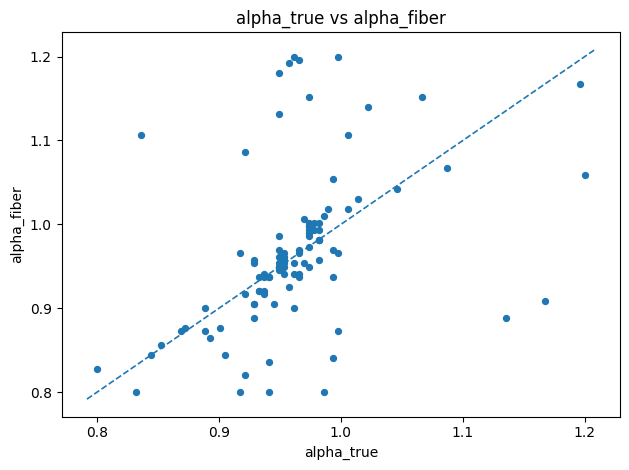

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 入力CSVを指定 ---
CSV_PATH = "alphas_by_rlz.csv"  # 例: あなたのCSVファイル名に変更

# --- 読み込み & 列チェック ---
df = pd.read_csv(CSV_PATH)
required = {"alpha_true", "alpha_fiber"}
if not required.issubset(set(df.columns)):
    raise ValueError(f"CSVに必要列 {required} がありません。列: {list(df.columns)}")

x = df["alpha_true"].values
y = df["alpha_fiber"].values

# --- プロット ---
plt.figure()
plt.scatter(x, y, s=18)                     # 点群（色指定なし）
mn = float(min(x.min(), y.min()))
mx = float(max(x.max(), y.max()))
pad = 0.02 * (mx - mn if mx > mn else 1.0)  # 余白

# y = x の基準線
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", lw=1.2)

plt.xlabel("alpha_true")
plt.ylabel("alpha_fiber")
plt.title("alpha_true vs alpha_fiber")
plt.tight_layout()

OUT_PNG = "alpha_true_vs_alpha_fiber.png"
plt.savefig(OUT_PNG, dpi=150)
print(f"Saved: {OUT_PNG}")
plt.show()

In [96]:
tmp = BAO(np.logspace(-2.5,0,50),z=0.15,Sigma_a=5.)
tmp_r,tmp_xi = tmp.calc_fourierTransform()
chi_true,alpha_true,param_true = tmp.least_squareFit(rmid,np.mean(xis_true,axis=0),cov,num=num)
idx_true = np.argmin(chi_true)
print(alpha_true[idx_true],param_true[idx_true])
chi_fiber,alpha_fiber,param_fiber = tmp.least_squareFit(rmid,np.mean(xis_fiber,axis=0),cov,num=num)
idx_fiber = np.argmin(chi_fiber)
print(alpha_fiber[idx_fiber],param_fiber[idx_fiber])

self.r [5.02338683e-04 5.07048918e-04 5.11803319e-04 ... 9.76937784e+04
 9.86098150e+04 9.95344409e+04]
0.9616161616161616 [ 1.19583125e+00  1.02177967e-03 -2.62778134e-01  1.81505589e+01]
0.9575757575757575 [ 1.16116468e+00  2.57712415e-03 -7.06215096e-01  4.31946172e+01]


/tmp/ipykernel_1457789/4007853174.py:35: DeprecationWarning: You are passing x=[0.00316228 0.00355648 0.00399982 0.00449843 0.0050592  0.00568987
 0.00639915 0.00719686 0.008094   0.00910298 0.01023774 0.01151395
 0.01294926 0.01456348 0.01637894 0.0184207  0.02071698 0.02329952
 0.02620399 0.02947052 0.03314425 0.03727594 0.04192267 0.04714866
 0.05302611 0.05963623 0.06707036 0.0754312  0.08483429 0.09540955
 0.10730309 0.12067926 0.13572288 0.1526418  0.17166979 0.19306977
 0.21713743 0.24420531 0.27464741 0.30888436 0.34738921 0.39069399
 0.43939706 0.49417134 0.55577366 0.62505519 0.70297321 0.79060432
 0.88915933 1.        ] as a positional argument. Please change your invocation to use keyword arguments. From SciPy 1.14, passing these as positional arguments will result in an error.
  return integrate.simpson(k**(n_s + 2.) * Window_func(k, 8.)**2. * transfer_func(initialized_q(k))**2., k) # (8.35)
/tmp/ipykernel_1457789/4007853174.py:35: DeprecationWarning: You are passing x=[1.